In [1]:
import subprocess
import os
from itertools import product
import concurrent.futures
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import lzma
import pickle

In [2]:
%%script echo skipping 

# Build Peregrine
subprocess.run(["sh", "build-peregrine.sh"], check=True, text=True, capture_output=True)

skipping


In [3]:
subprocess.run(["g++", "generate-variate-graph.cpp", "-O3", "-o", "generate-variate-graph"], check=True, text=True, capture_output=True)

CompletedProcess(args=['g++', 'generate-variate-graph.cpp', '-O3', '-o', 'generate-variate-graph'], returncode=0, stdout='', stderr='')

In [4]:
def save_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with open(filename, "w") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving graph to {filename}: {e}")

def load_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with open(filename, "r") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u, v)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def save_compressed_graph_nx(graph: nx.Graph, filename: str) -> None:
    try:
        with lzma.open(filename, "wt") as f:
            for edge in graph.edges():
                f.write(f"{edge[0] + 1} {edge[1] + 1}\n")
    except Exception as e:
        print(f"Error saving compressed graph to {filename}: {e}")

def load_compressed_graph_nx(filename: str) -> nx.Graph:
    graph = nx.Graph()
    try:
        with lzma.open(filename, "rt") as f:
            for line in f:
                u, v = map(int, line.strip().split())
                graph.add_edge(u - 1, v - 1)
    except Exception as e:
        print(f"Error loading compressed graph from {filename}: {e}")
    return graph

def relabel_graph_nx(graph: nx.Graph) -> nx.Graph:
    mapping = {old_label: new_label for new_label, old_label in enumerate(graph.nodes())}
    return nx.relabel_nodes(graph, mapping)

def count_subgraphs(graph: nx.Graph, subgraph: nx.Graph, nthreads: int) -> int:
    save_graph_nx(relabel_graph_nx(graph), "graph.txt")
    save_graph_nx(relabel_graph_nx(subgraph), "subgraph.txt")

    try:
        result = subprocess.run(
            ["./peregrine/bin/count", "graph.txt", "subgraph.txt", str(nthreads)],
            check=True,
            text=True,
            capture_output=True,
        )
        
        os.remove("graph.txt")
        os.remove("subgraph.txt")

        return int(result.stdout.split(":")[2].strip())
    except:
        os.remove("graph.txt")
        os.remove("subgraph.txt")
        
        print("Error occurred while counting subgraphs")
        return -1

In [5]:
def generate_variate_graph(n: int, m: int, p: float, alpha: float | None = None, graph_type: str = "standard", file_identifier: str = "") -> nx.Graph:
    if graph_type == "standard":
        graph_type = "0"
    elif graph_type == "power-based":
        if alpha is None:
            print("Alpha parameter must be provided for power-based graph type")
            return None
        graph_type = "1"
    elif graph_type == "log-based":
        graph_type = "2"
    else:
        print(f"Graph type {graph_type} is not supported")
        return None

    result = subprocess.run(
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt"] if alpha is None else
            ["./generate-variate-graph", str(n), str(m), str(p), graph_type, f"graph_{file_identifier}.txt", str(alpha)],
            check=True,
            text=True,
            capture_output=True,
        )
    
    if result.returncode != 0:
        print(f"Error generating graph: {result.stderr}")
        return None

    g = load_graph_nx(f"graph_{file_identifier}.txt")
    os.remove(f"graph_{file_identifier}.txt")
    
    return g

In [6]:
N_VALUES = list(range(50, 5001, 150))
M_VALUES = [2, 3, 4, 5, 6]
P_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ALPHA_SUB_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ALPHA_SUPER_VALUES = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]

MAX_WORKERS = 7

SAMPLES_PER_CONFIG = 10

### Generating Standard Preferential Attachment Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/without-acceptance/preferential-attachment/graphs/"

def generate_single_graph(sample_index: int, n: int, m: int) -> None:
    graph = generate_variate_graph(n=n, m=m, p=1.0, alpha=None, graph_type="standard", file_identifier=f"s{sample_index}_n{n}_m{m}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}.txt.xz"
    save_compressed_graph_nx(graph, filename)


index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                futures.append(executor.submit(generate_single_graph, sample_index, n, m))

        for future in concurrent.futures.as_completed(futures):
            future.result()


### Generating Standard Preferential Attachment With Acceptance Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/with-acceptance/preferential-attachment/graphs/"

def generate_single_graph_with_acceptance(sample_index: int, n: int, m: int, p: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=p, alpha=None, graph_type="standard", file_identifier=f"s{sample_index}_n{n}_m{m}_p{int(p*100)}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_p{int(p*100)}.txt.xz"
    save_compressed_graph_nx(graph, filename)


index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for p in P_VALUES:
                    futures.append(executor.submit(generate_single_graph_with_acceptance, sample_index, n, m, p))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Sublinear Preferential Attachment Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/without-acceptance/sublinear-preferential-attachment/graphs/"

def generate_single_graph(sample_index: int, n: int, m: int, alpha: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=1.0, alpha=alpha, graph_type="power-based", file_identifier=f"s{sample_index}_n{n}_m{m}_a{alpha}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_a{alpha}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for alpha in ALPHA_SUB_VALUES:
                    futures.append(executor.submit(generate_single_graph, sample_index, n, m, alpha))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Sublinear Preferential Attachment With Acceptance Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/with-acceptance/sublinear-preferential-attachment/graphs/"

def generate_single_graph_with_acceptance(sample_index: int, n: int, m: int, p: float, alpha: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=p, alpha=alpha, graph_type="power-based", file_identifier=f"s{sample_index}_n{n}_m{m}_p{int(p*100)}_a{alpha}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_p{int(p*100)}_a{alpha}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for p in P_VALUES:
                    for alpha in ALPHA_SUB_VALUES:
                        futures.append(executor.submit(generate_single_graph_with_acceptance, sample_index, n, m, p, alpha))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Superlinear Preferential Attachment Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/without-acceptance/superlinear-preferential-attachment/graphs/"

def generate_single_graph(sample_index: int, n: int, m: int, alpha: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=1.0, alpha=alpha, graph_type="power-based", file_identifier=f"s{sample_index}_n{n}_m{m}_a{alpha}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_a{alpha}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for alpha in ALPHA_SUPER_VALUES:
                    futures.append(executor.submit(generate_single_graph, sample_index, n, m, alpha))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Superlinear Preferential Attachment With Acceptance Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/with-acceptance/superlinear-preferential-attachment/graphs/"

def generate_single_graph_with_acceptance(sample_index: int, n: int, m: int, p: float, alpha: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=p, alpha=alpha, graph_type="power-based", file_identifier=f"s{sample_index}_n{n}_m{m}_p{int(p*100)}_a{alpha}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_p{int(p*100)}_a{alpha}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for p in P_VALUES:
                    for alpha in ALPHA_SUPER_VALUES:
                        futures.append(executor.submit(generate_single_graph_with_acceptance, sample_index, n, m, p, alpha))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Log-Based Preferential Attachment Graphs

In [ ]:
DESTINATION_FOLDER = "generated-data/without-acceptance/log-based-preferential-attachment/graphs/"

def generate_single_graph_log_based(sample_index: int, n: int, m: int) -> None:
    graph = generate_variate_graph(n=n, m=m, p=1.0, alpha=None, graph_type="log-based", file_identifier=f"s{sample_index}_n{n}_m{m}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                futures.append(executor.submit(generate_single_graph_log_based, sample_index, n, m))

        for future in concurrent.futures.as_completed(futures):
            future.result()

### Generating Log-Based Preferential Attachment Graphs With Acceptance

In [ ]:
DESTINATION_FOLDER = "generated-data/with-acceptance/log-based-preferential-attachment/graphs/"

def generate_single_graph_log_based_with_acceptance(sample_index: int, n: int, m: int, p: float) -> None:
    graph = generate_variate_graph(n=n, m=m, p=p, alpha=None, graph_type="log-based", file_identifier=f"s{sample_index}_n{n}_m{m}_p{int(p*100)}")

    filename = f"{DESTINATION_FOLDER}/sample{sample_index}/graph_n{n}_m{m}_p{int(p*100)}.txt.xz"
    save_compressed_graph_nx(graph, filename)

index_zero = len(os.listdir(DESTINATION_FOLDER)) + 1
for sample_index in range(index_zero, index_zero + SAMPLES_PER_CONFIG + 1):
    print(f"Generating sample {sample_index}...")
    
    os.makedirs(f"{DESTINATION_FOLDER}sample{sample_index}/", exist_ok=True)

    with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = []
        for n in N_VALUES:
            for m in M_VALUES:
                for p in P_VALUES:
                    futures.append(executor.submit(generate_single_graph_log_based_with_acceptance, sample_index, n, m, p))

        for future in concurrent.futures.as_completed(futures):
            future.result()

In [ ]:
ALL_GENERATED_DATA = [
   ("generated-data/without-acceptance/preferential-attachment/", 
   {
      "n": N_VALUES,
      "m": M_VALUES
   }),
   ("generated-data/with-acceptance/preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "p": [int(p*100) for p in P_VALUES]    
   }),

   ("generated-data/without-acceptance/sublinear-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "a": ALPHA_SUB_VALUES
   }),
   ("generated-data/with-acceptance/sublinear-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "p": [int(p*100) for p in P_VALUES],
      "a": ALPHA_SUB_VALUES
   }),

   ("generated-data/without-acceptance/superlinear-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "a": ALPHA_SUPER_VALUES
   }),
   ("generated-data/with-acceptance/superlinear-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "p": [int(p*100) for p in P_VALUES],
      "a": ALPHA_SUPER_VALUES
   }),

   ("generated-data/without-acceptance/log-based-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
   }),
   ("generated-data/with-acceptance/log-based-preferential-attachment/",
   {
      "n": N_VALUES,
      "m": M_VALUES,
      "p": [int(p*100) for p in P_VALUES],
   })
]

### Averaging Multiple Histograms

In [ ]:
def genarate_degree_histogram(graph: nx.Graph) -> dict:
    degree_sequence = [d for _, d in graph.degree()]
    degree_count = np.bincount(degree_sequence)
    histogram = {degree: count for degree, count in enumerate(degree_count) if count > 0}

    return histogram

def average_degree_histograms(graphs: list) -> dict:
    aggregate_degrees = {}
    counts = {}
    for graph in graphs:
        histogram = genarate_degree_histogram(graph)
        for degree, count in histogram.items():
            if degree in aggregate_degrees:
                aggregate_degrees[degree] += count
                counts[degree] += 1
            else:
                aggregate_degrees[degree] = count
                counts[degree] = 1

    average_histogram = {degree: aggregate_degrees[degree] / counts[degree] for degree in aggregate_degrees}

    return average_histogram

In [ ]:
for path, params in ALL_GENERATED_DATA:
    average_histograms = {}
    for param_tuple in product(*params.values()):
        param_str = "_".join(f"{key}{value}" for key, value in zip(params.keys(), param_tuple))

        graphs = []
        for sample_path in os.listdir(f"{path}graphs/"):
            graph_filename = f"{path}graphs/{sample_path}/graph_{param_str}.txt.xz"
            if os.path.exists(graph_filename):
                graph = load_compressed_graph_nx(graph_filename)
                graphs.append(graph)
            else:
                print(f"Graph file {graph_filename} does not exist.")

        average_histograms[param_tuple] = average_degree_histograms(graphs)  

    with open(f"{path}averaged-plots/average_degree_histograms.pkl", "wb") as f:
        pickle.dump(average_histograms, f)

In [ ]:
def plot_average_histograms(path: str, params: dict[str, list[str]]) -> None:
    filename = f"{path}averaged-plots/average_degree_histograms.pkl"
    with open(filename, "rb") as f:
        data = pickle.load(f)

    for param, values in params.items():
        if len(values) == 0:
            print(f"No values provided for parameter {param}.")
            return

    single_params = [key for key, values in params.items() if len(values) == 1]
    multiple_params = [key for key, values in params.items() if len(values) > 1]

    if len(single_params) + len(multiple_params) < 2:
        print("No enough params provided")

    if len(multiple_params) > 1:
        print("Cannot plot more than one varying parameter at a time.")
        return
        
    selected_samples = []
    for param_tuple in product(*params.values()):
        if param_tuple not in data:
            print("Passed invalid params")
            return 
        
        selected_samples.append(data[param_tuple])
    
    if len(multiple_params) == 0:
        multiple_params = [single_params[0]]
        single_params = single_params[1:]
    
    single_params_str = ", ".join(f"{param}={params[param][0]}" for param in single_params)
    varying_param = params[multiple_params[0]]

    if len(varying_param) == 1:
        fig, ax = plt.subplots(figsize=(8, 6))
        histogram = selected_samples[0]
        ax.bar(histogram.keys(), histogram.values())
        ax.set_title(f"{single_params_str}, {multiple_params[0]}={varying_param[0]}")
        ax.set_xlabel("Degree")
        ax.set_ylabel("Average Count")

        fig.tight_layout()
    else:
        fig, axs = plt.subplots(1, len(varying_param), figsize=(5 * len(varying_param), 5), sharey=True)
        for i, value in enumerate(varying_param):
            histogram = selected_samples[i]
            axs[i].bar(histogram.keys(), histogram.values())
            axs[i].set_title(f"{single_params_str}, {multiple_params[0]}={value}")
            axs[i].set_xlabel("Degree")
            if i == 0:
                axs[i].set_ylabel("Average Count")

            fig.tight_layout()

In [ ]:
plot_average_histograms("generated-data/without-acceptance/preferential-attachment/", {"n": [500], "m": [2, 3, 4]})

In [ ]:
plot_average_histograms("generated-data/with-acceptance/preferential-attachment/", {"n": [500], "m": [4], "p": [20, 50, 80]})

In [ ]:
plot_average_histograms("generated-data/without-acceptance/sublinear-preferential-attachment/", {"n": [500], "m": [3], "a": [0.3, 0.6, 0.9]})

In [ ]:
plot_average_histograms("generated-data/with-acceptance/sublinear-preferential-attachment/", {"n": [500], "m": [3], "p": [20, 40, 70], "a": [0.6]})

In [ ]:
plot_average_histograms("generated-data/without-acceptance/superlinear-preferential-attachment/", {"n": [500], "m": [3, 4, 5], "a": [1.25]})

In [ ]:
plot_average_histograms("generated-data/with-acceptance/superlinear-preferential-attachment/", {"n": [500], "m": [4], "p": [50, 70, 90], "a": [1.25]})

In [ ]:
plot_average_histograms("generated-data/without-acceptance/log-based-preferential-attachment/", {"n": [500], "m": [2, 3, 4]})

In [ ]:
plot_average_histograms("generated-data/with-acceptance/log-based-preferential-attachment/", {"n": [500], "m": [4], "p": [20, 50, 80]})

### Counting Subgraphs in Generated Graphs

In [8]:
SUBGRAPHS_TO_COUNT = {
    # "triangle": nx.complete_graph(3),
    "square": nx.cycle_graph(4),
    # "star_4": nx.star_graph(3),
    "clique_4": nx.complete_graph(4),
    "complete_bipartite_3_3": nx.complete_bipartite_graph(3, 3),
    # "star_5": nx.star_graph(4),
    # "clique_5": nx.complete_graph(5),
}

In [ ]:
for path, params in ALL_GENERATED_DATA:
    print(path)
    counts_per_subgraph = {}
    for param_tuple in product(*params.values()):
        print(param_tuple)
        param_str = "_".join(f"{key}{value}" for key, value in zip(params.keys(), param_tuple))
        counts = {subgraph_name: [] for subgraph_name in SUBGRAPHS_TO_COUNT.keys()}
        for sample_path in os.listdir(f"{path}graphs/"):
            graph_filename = f"{path}graphs/{sample_path}/graph_{param_str}.txt.xz"
            if os.path.exists(graph_filename):
                graph = load_compressed_graph_nx(graph_filename)
                for subgraph_name, subgraph in SUBGRAPHS_TO_COUNT.items():
                    count = count_subgraphs(graph, subgraph, MAX_WORKERS)
                    counts[subgraph_name].append(count)
            else:
                print(f"Graph file {graph_filename} does not exist.")
        
        counts_per_subgraph[param_tuple] = counts

    for subgraph_name in SUBGRAPHS_TO_COUNT.keys():
        with open(f"{path}counts/{subgraph_name}_counts.pkl", "wb") as f:
            pickle.dump({key: counts_per_subgraph[key][subgraph_name] for key in counts_per_subgraph.keys()}, f)

In [53]:
def plot_average_subgraph_counts(path: str, subgraph_name: str, n_values: list[int], params: dict[str, list[str]]) -> None:
    filename = f"{path}counts/{subgraph_name}_counts.pkl"
    with open(filename, "rb") as f:
        data = pickle.load(f)

    single_params = [key for key, values in params.items() if len(values) == 1]
    multiple_params = [key for key, values in params.items() if len(values) > 1]

    if len(single_params) + len(multiple_params) < 1:
        print("No enough params provided")

    if len(multiple_params) > 1:
        print("Cannot plot more than one varying parameter at a time.")
        return

    selected_samples = []
    for param_tuple in product(n_values, *params.values()):
        if param_tuple not in data:
            print("Passed invalid params")
            return 
        
        selected_samples.append(sum(data[param_tuple]) / len(data[param_tuple]))


    varying_params = params[multiple_params[0]]
    series_selected_samples = []
    for vp in range(len(varying_params)):
        series = []
        for i in range(len(n_values)):
            index = i * len(varying_params) + vp
            series.append(selected_samples[index])
        series_selected_samples.append(series)

    plt.figure(figsize=(8, 6))
    for vp_index, vp in enumerate(varying_params):
        plt.plot(n_values, series_selected_samples[vp_index], marker='o', label=f"{multiple_params[0]}={vp}")
    single_params_str = ", ".join(f"{param}={params[param][0]}" for param in single_params)
    plt.title(f"Average {subgraph_name} counts ({single_params_str})" if single_params_str else f"Average {subgraph_name} counts")
    plt.xlabel("Number of nodes")
    plt.ylabel(f"Average {subgraph_name} count")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

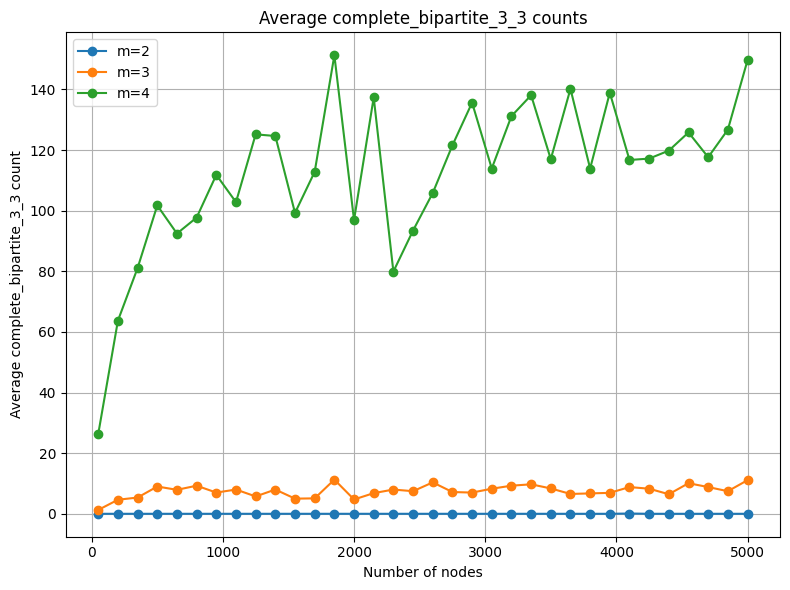

In [62]:
plot_average_subgraph_counts("generated-data/without-acceptance/preferential-attachment/", "complete_bipartite_3_3", N_VALUES, {"m": M_VALUES[:3]})

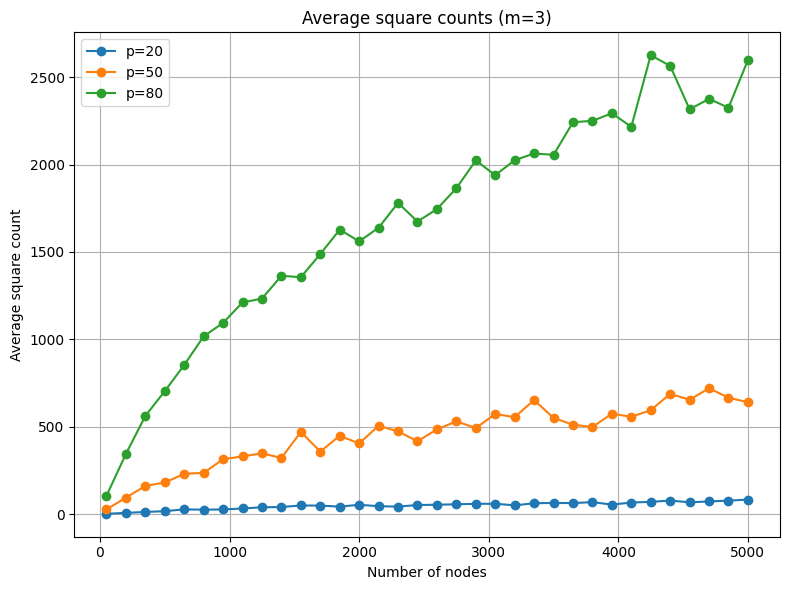

In [63]:
plot_average_subgraph_counts("generated-data/with-acceptance/preferential-attachment/", "square", N_VALUES, {"m": [3], "p": [20, 50, 80]})

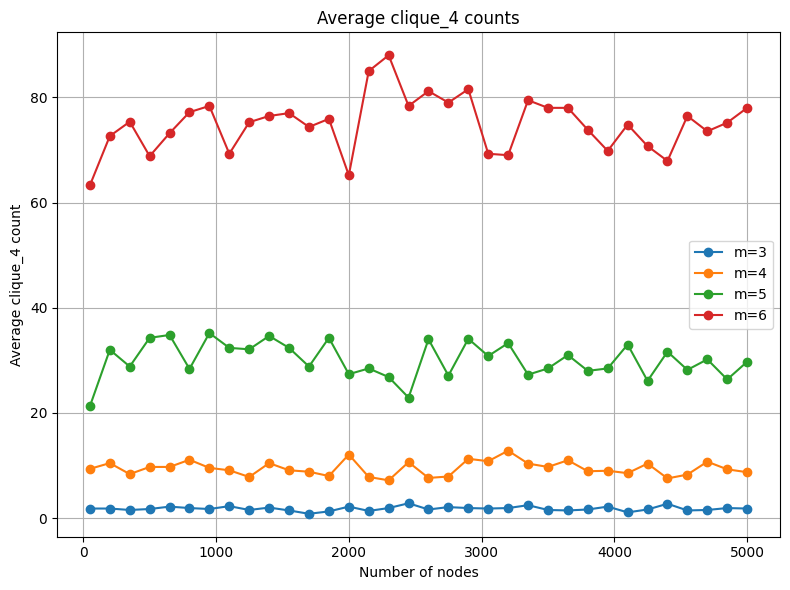

In [66]:
plot_average_subgraph_counts("generated-data/without-acceptance/log-based-preferential-attachment/", "clique_4", N_VALUES, {"m": M_VALUES[1:5]})

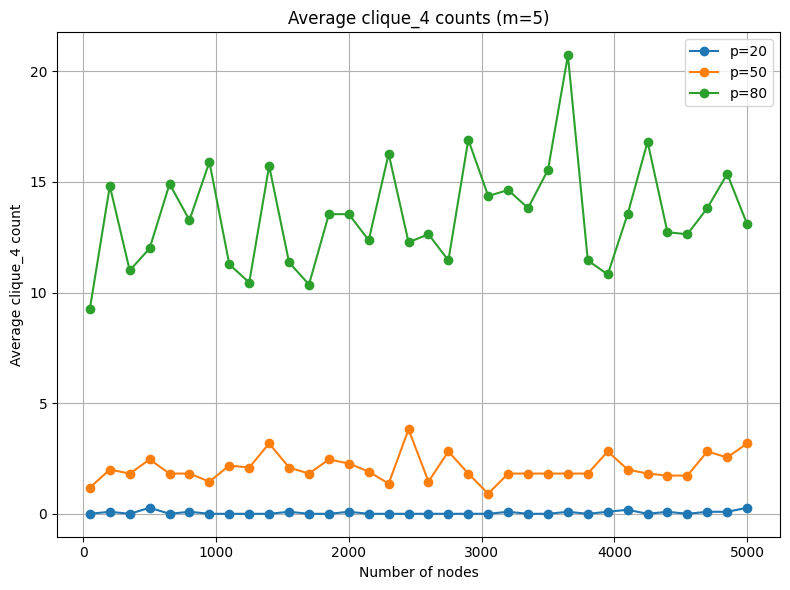

In [67]:
plot_average_subgraph_counts("generated-data/with-acceptance/log-based-preferential-attachment/", "clique_4", N_VALUES, {"m": [5], "p": [20, 50, 80]})